<a href="https://colab.research.google.com/github/nehaj2026/undergrad_ml_assignments/blob/main/NJ_assignment_wrangling_and_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Wrangling and EDA
### Foundations of Machine Learning

In [ ]:
! git clone https://github.com/nehaj2026/scratchpad

Cloning into 'scratchpad'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 36 (delta 9), reused 6 (delta 6), pack-reused 23 (from 1)
Receiving objects: 100% (36/36), 64.98 KiB | 2.83 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [ ]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

Download complete
Extracting data files...
Data extracted


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `airbnb_NYC.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? For the remaining missing values, replace the `np.nan/None` values with the label `Missing`.
3. Dummy variable: For `metabric.csv`, convert the `Overall Survival Status` variable into a dummy/binary variable, taking the value 0 if the patient is deceased and 1 if they are living.
4. Missing values: For `airbnb_NYC.csv`, determine how many missing values of `Review Scores Rating` there are. Create a new variable, in which you impute the median score for non-missing observations to the missing ones. Why might this bias or otherwise negatively impact your results?

In [40]:
df = pd.read_csv('/content/data/airbnb_NYC.csv', encoding='latin-1')
df['Price'].describe()

,Price
count,30478
unique,511
top,150
freq,1481


In [43]:
#Question 1.1
#Cleaning Airbnb Price Variable
df = pd.read_csv('/content/data/airbnb_NYC.csv', encoding='latin-1')
df['Price'].describe()

# Since price is an object, I will convert it to numeric and replace the "," with nothing so that values above 1000 convert properly.
New_Price = df['Price'].str.replace(',', '')
Final_Price = pd.to_numeric(New_Price)

# Missing Values after cleaning
Missing_Count = New_Price.isna().sum()
print(Missing_Count)
#After replacing the ","s with "", there are no missing values.


0


In [ ]:
df1 = pd.read_csv('/content/data/mn_police_use_of_force.csv')
df1['subject_injury'].value_counts(dropna = False)
#There are 9848 missing values before cleaning

,count
subject_injury,
NaN,9848
Yes,1631
No,1446


In [ ]:
#Question 1.2
#Importing dataset
df1 = pd.read_csv('/content/data/mn_police_use_of_force.csv')

#Replacing na with Missing
df1['subject_injury'] = df1['subject_injury'].fillna('Missing')

#Proportion of values missing after cleaning
df1['subject_injury'].value_counts(dropna = False)
#Missing = 9848, Yes = 1631, No = 1446
9848/(9848+1631+1446)
# 76.19% of values are missing.

#Crosstabulation of subject injury and force type
pd.crosstab(df1['subject_injury'], df1['force_type'])

#Patterns emerging from crosstab:
#Force types like bodily force and chemical irritant have the most missing subject injury instances. This presents a trend of more severe injury types like those involving firearms and lethal weapons being less likely to be left "Missing" since these have far lower counts of "Missing" instances.


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
Missing,2,7051,1421,0,27,74,87,0,170,31,985
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172


In [ ]:
#Question 1.3
#Replacing Alive and Deceased to be a dummy/binary variable
df2 = pd.read_csv('/content/data/metabric.csv')
df2['Overall Survival Status'] = df2['Overall Survival Status'].replace('1:DECEASED', 0)
df2['Overall Survival Status'] = df2['Overall Survival Status'].replace('0:LIVING', 1)
df2['Overall Survival Status']

/tmp/ipython-input-2199258647.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2['Overall Survival Status'] = df2['Overall Survival Status'].replace('0:LIVING', 1)


,Overall Survival Status
0,1
1,0
2,1
3,0
4,0
...,...
1338,1
1339,0
1340,1
1341,0


In [ ]:
#Question 1.4
#Number of missing Review Scores Rating
df3 = pd.read_csv('/content/data/airbnb_NYC.csv', encoding='latin-1')
df3['Review Scores Rating'].isna().sum()
#There are 8323 missing Review Score Ratings

#Adding a new variable with mean Review Score Ratings
df3['New Median Rating'] = df3['Review Scores Rating'].fillna(df3['Review Scores Rating'].mean())
df3['New Median Rating'].isna().sum()
#There are now zero missing scores, all missing were successfully imputed.

#Biasing results:
#This biases results because it ignores the inherent variability in score ratings. By just imputing the average of review ratings that are present, the new median rating variable is biasing estimates towards the mean and masking possible connections or trends that may be present in the data had actual review scores been imputed.

np.int64(0)

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work. What does work?
2. Drop any columns that do not contain data.
3. What is an observation? Carefully justify your answer, and explain how it affects your choices in cleaning and analyzing the data.
4. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
5. Clean the Age variable and make a histogram of the ages of the victims.
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Thoughts?

In [44]:
#Question 2.1
from google.colab import files
uploaded = files.upload()
df4 = pd.read_excel('GSAF5.xls')
df4

# I had to manually import the file to google colab since it is an excel file

Saving GSAF5.xls to GSAF5.xls


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,29th January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,...,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29th January,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,...,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24th January,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,...,1.7m Seven Gill shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,...,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7069,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,...,NaN,"H. Taunton; N. Bartlett, p. 234",ND-0005-RoebuckBay.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0005,ND.0005,6.0,NaN,NaN
7070,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,...,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND-0004-Ahmun.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0004,ND.0004,5.0,NaN,NaN
7071,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,...,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND-0003-Ocracoke_1900-1905.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0003,ND.0003,4.0,NaN,NaN
7072,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,...,NaN,"The Sun, 10/20/1938",ND-0002-JulesPatterson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0002,ND.0002,3.0,NaN,NaN


In [ ]:
#Question 2.2
#Check which columns do not have data
df4.isna().mean().sort_values(ascending = False)
#Both of the unnamed columns have 99.99% and 99.97% of cell values missing, so I will drop them.

#Drop columns without data
df4 = df4.drop(columns = 'Unnamed: 21')
df4 = df4.drop(columns = 'Unnamed: 22')
df4

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Fatal Y/N,Time,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order
0,29th January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,...,Y,?,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...,NaN,NaN,NaN,NaN,NaN,NaN
1,29th January,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,...,N,1100hrs,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN
2,24th January,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,...,N,1815hrs,1.7m Seven Gill shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN
3,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,...,N,0830hrs,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN
4,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,...,N,1145hrs,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7069,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,...,Y,NaN,NaN,"H. Taunton; N. Bartlett, p. 234",ND-0005-RoebuckBay.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0005,ND.0005,6.0
7070,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,...,Y,NaN,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND-0004-Ahmun.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0004,ND.0004,5.0
7071,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,...,Y,NaN,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND-0003-Ocracoke_1900-1905.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0003,ND.0003,4.0
7072,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,...,Y,NaN,NaN,"The Sun, 10/20/1938",ND-0002-JulesPatterson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0002,ND.0002,3.0


#Question 2.3
I describe an observation as a row or tuple of values relating to each attribute (column). Applying this to the last question, I removed the columns that were denoted as "Unnamed" because these columns had no values (NaN) for all tuples. Thus, these columns were not providing real information, so I removed these columns. It is important to note I did not remove columns that had NaN present for some tuples, but not all tuples as these columns did have valuable information for some tuples that I constituted as an observation.

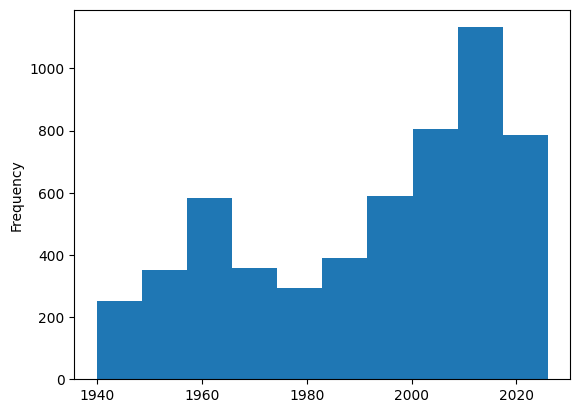

In [ ]:
#Question 2.4
#Cleaning Year
df4['Year'] = pd.to_numeric(df4['Year'], errors = 'coerce')
df4.loc[df4['Year'] <= 0, 'Year'] = np.nan
df4['Year'] = df4['Year'].round().astype('Int64')

#Describe range of values
df4['Year'].max()-df4['Year'].min()
#Max = 2026. Min = 5. Range = 2021.

#Filtering
Year_filtered = df4.loc[df4['Year'] >= 1940, 'Year'].copy()
Year_filtered

#Histogram to view if attacks are increasing or decreasing over time
import matplotlib.pyplot as plt
Year_filtered.plot.hist()
plt.show()

#The histogram displays that attacks are increasing over time, especially since 2000.

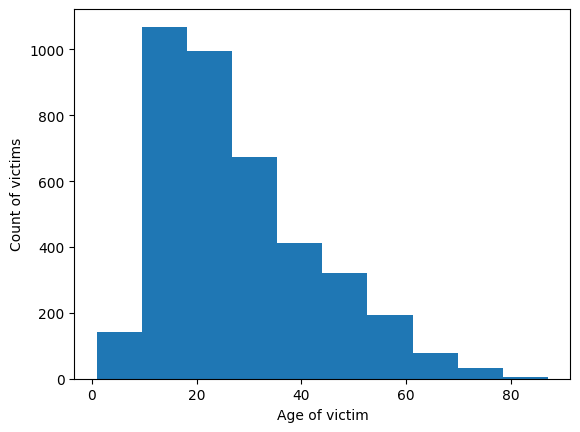

In [ ]:
#Question 2.5
#Cleaning Age
df4['Age'] = df4['Age'].replace('?', np.nan)
df4['Age'] = pd.to_numeric(df4['Age'], errors='coerce')
df4.loc[df4['Age'] <= 0, 'Age'] = np.nan
df4['Age'] = df4['Age'].round().astype('Int64')
df4['Age'].value_counts()

#Plotting histogram
df4['Age'].dropna().plot.hist()
plt.xlabel('Age of victim')
plt.ylabel('Count of victims')
plt.show()

In [ ]:
#Question 2.6
#Cleaning Type
df4['Type'].value_counts()
df4['Type'] = df4['Type'].replace('Invalid', 'Unknown')
df4['Type'] = df4['Type'].replace('Watercraft', 'Unknown')
df4['Type'] = df4['Type'].replace('Sea Disaster', 'Unknown')
df4['Type'] = df4['Type'].replace('Questionable', 'Unknown')
df4['Type'] = df4['Type'].replace('Boat', 'Unknown')
df4['Type'] = df4['Type'].replace('unprovoked', 'Unprovoked')
df4['Type'] = df4['Type'].replace('Unconfirmed', 'Unknown')
df4['Type'] = df4['Type'].replace('?', 'Unknown')
df4['Type'] = df4['Type'].replace('Unverified', 'Unknown')
df4['Type'] = df4['Type'].replace('Under investigation', 'Unknown')
df4['Type'] = df4['Type'].replace('Provoked ', 'Provoked')
df4['Type'] = df4['Type'].replace(' Provoked', 'Provoked')
df4['Type'].value_counts()

#Proportion of attacks that are unprovoked
df4['Type'].value_counts(normalize = True)
# 74.06% of attacks are unprovoked

,proportion
Type,
Unprovoked,0.740646
Unknown,0.168084
Provoked,0.091270


In [ ]:
#Question 2.7
#Clean Fatal Y/N
df4['Fatal Y/N'].value_counts(dropna=False)
df4['Fatal Y/N'] = df4['Fatal Y/N'].replace('N ', 'N')
df4['Fatal Y/N'] = df4['Fatal Y/N'].replace(' N', 'N')
df4['Fatal Y/N'] = df4['Fatal Y/N'].replace('y', 'Y')
df4['Fatal Y/N'] = df4['Fatal Y/N'].fillna('Unknown')
df4['Fatal Y/N'] = df4['Fatal Y/N'].replace('UNKNOWN', 'Unknown')
df4['Fatal Y/N'] = df4['Fatal Y/N'].replace('F', 'Unknown')
df4['Fatal Y/N'] = df4['Fatal Y/N'].replace('M', 'Unknown')
df4['Fatal Y/N'] = df4['Fatal Y/N'].replace('Nq', 'Unknown')
df4['Fatal Y/N'] = df4['Fatal Y/N'].replace('n', 'Unknown')
df4['Fatal Y/N'] = df4['Fatal Y/N'].replace(2017, 'Unknown')
df4['Fatal Y/N'] = df4['Fatal Y/N'].replace('Y x 2', 'Unknown')

df4['Fatal Y/N'].value_counts(dropna=False)


,count
Fatal Y/N,
N,4941
Y,1489
Unknown,644


In [ ]:
#Question 2.8
pd.crosstab(df4['Type'], df4['Fatal Y/N'], normalize = 'index')

# Provoked attacks are fatal 3.26% of the time
# Unprovoked attacks are fatal 24.26% of the time
#This is surprising to me since I would have assumed the shark would be more angry or murderous when it was provoked.

Fatal Y/N,N,Unknown,Y
Type,,,
Provoked,0.951863,0.015528,0.032609
Unknown,0.370995,0.463744,0.165261
Unprovoked,0.742250,0.015117,0.242633


**Q3.** Open the "tidy_data.pdf" document available in `https://github.com/ds4e/wrangling`, which is a paper called *Tidy Data* by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  2. Read the introduction. What is the "tidy data standard" intended to accomplish?
  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."
  4. Read Section 2.2. How does Wickham define values, variables, and observations?
  5. How is "Tidy Data" defined in section 2.3?
  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?
  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?

# Question 3 Responses:

1.   The paper is about tidy data, which is a structure for datasets that allows for easier manipulation and analyzation of the model. The goal of tidy datasets is to minimize the time spent cleaning data.
2.   The tidy data standard was created to have a uniform method for structuring data and to eliminate wasted time on repetitive data cleaning. The introduction dives into how data cleaning must be performed throughout the course of analysis and establishes this wasted time as the reason for the creation of the tidy data standard.
3. The first sentence refers to tidy datasets being like families to allude to tidy datasets having a uniform structure. The second half of the sentence refers to messy datasets as being messy in their own way because there are a plethora of ways messy datasets can have issues. The second sentence is alluding to the fact that when one sees a dataset, it is easier to discern what the observations and variables are because the dataset provides structure for this, but without having a dataset in front of you, it is difficult to define what an observation or variable is or to have a generally accepted definition for either term.
4. Values are defined as the individual cells/entries which are typically numbers if they are quantitative or strings if they are qualitative. variables are the values that measure the same underlying attribute. Observations contain all values measured on the same unit and these are measured across attributes. All of this fits into the formation of each value belonging to a variable and an observation.
5. Tidy data is defined by each variable being a column in the dataset, each observation being a row, and these observational units making a table. All of these criteria must be met for data to be tidy.
6. The five most common problems with messy datasets are as follows: 1) column headers are values, not variable names. 2) multiple variables are stored in one column. 3) variables are stored in both rows and columns. 4) multiple types of observational units are stored in the same table. 5) a single observational unit is stored in multiple tables. Table 4 is messy because the income values should be a variable instead of column names. Melting a dataset refers to taking columns that represent values and converting them into rows in order to end up with a column with the original column names as values and a column that contains the corresponding values.
7. Table 11 is messy because the element column has variable names in it and not values. All of the "d_" columns should not be columns, they should be values of a variable. Table 12 is tidy because the variables of tmax and tmin were transformed to being column headers, and this is directly "melting" the dataset.

**Q4.** This question looks at financial transfers from international actors to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going?

For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
5. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions.
6. Which giftors provide the most money, in total?

In [ ]:
#Question 4.1
#Loading the Foreign Gifts Dataset
df5 = pd.read_csv('/content/data/ForeignGifts_edu.csv')
df5.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


Text(0, 0.5, 'Count')

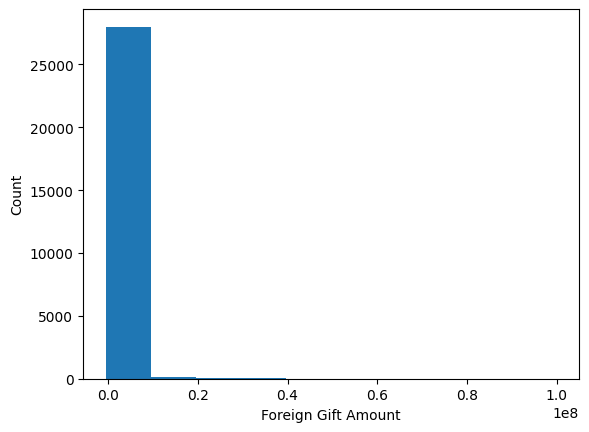

In [ ]:
#Question 4.2
#Foreign gift amount histogram
df5['Foreign Gift Amount'].value_counts()
df5['Foreign Gift Amount'].plot.hist()
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Count')

#Foreign gift amount description
#The distribution of foreign gift amounts have a strong right skew, and most of the foreign gift amounts are close to zero. Other than these lower dollar amount foreign gifts, there are a few outliers with higher gift amounts.

In [ ]:
#Question 4.3
#Value counts table
df5['Gift Type'].value_counts(normalize = True)

#61.2% of gifts are contracts
#38.75% of gifts are monetary gifts
#.039% of gifts are real estate

,proportion
Gift Type,
Contract,0.612097
Monetary Gift,0.387513
Real Estate,0.000390


In [ ]:
#Question 4.4 (Part 1)
#Top 15 countries by number of gifts
df5.groupby('Country of Giftor') \
.count()['Foreign Gift Amount'] \
.sort_values(ascending = False) \
.head(15)

# The top countries in terms of the number of gifts are England, China, Canada, Japan, Switzerland, Saudi Arabia, France, Germany, Hong Kong, South Korea, Qatar, The Netherlands, Korea, India, Taiwan

,Foreign Gift Amount
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [ ]:
#Question 4.4 (Part 2)
#Top 15 countries by total amount given
df5.groupby('Country of Giftor') \
.sum()['Foreign Gift Amount'] \
.sort_values(ascending = False) \
.head(15)

# The top countries by total amount given are Qatar, England, China, Saudi Arabia, Bermuda, Canada, Hong Kong, Japan, Switzerland, India, Germany, UAE, France, Singapore, Australia

,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


In [ ]:
#Question 4.5 (Part 1)
#Top 15 instituions by total amount of money received
df5.groupby('Institution Name') \
.sum()['Foreign Gift Amount'] \
.sort_values(ascending = False) \
.head(15)

#The top 15 institutions in terms of total amount of money received are Carnegie Mellon, Cornell, Harvard, MIT, Yale, Texas A&M, Johns Hopkins, Northwestern, Georgetown, UChicago, UC Boulder, Duke, BYU, Stanford, UT MD Cancer Center

,Foreign Gift Amount
Institution Name,
Carnegie Mellon University,1477922504
Cornell University,1289937761
Harvard University,954803610
Massachusetts Institute of Technology,859071692
Yale University,613441311
Texas A&M University,521455050
Johns Hopkins University,502409595
Northwestern University,402316221
Georgetown University,379950511


<Axes: ylabel='Frequency'>

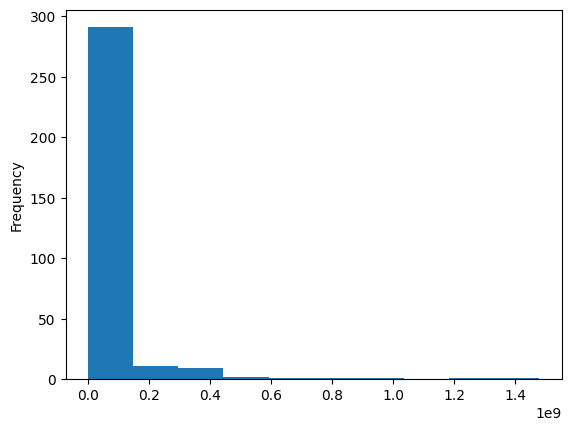

In [ ]:
#Question 4.5 (Part 2)
#Histogram of total amount received by all institutions
institution_histogram = (df5.groupby('Institution Name') ['Foreign Gift Amount'].sum())
institution_histogram.plot.hist()

In [ ]:
#Question 4.6
#Top giftors who provide the most money
df5.groupby('Giftor Name') \
.sum()['Foreign Gift Amount'] \
.sort_values(ascending = False) \
.head(15)

# The top giftors in total are the Qatar Foundation, Qatar Foundation/Qatar National Res, and the Quatar Foundation for Education. I also listed the rest of the top 15 giftors below.

,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


**Q5.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `college_completion.csv` dataset from the US Department of Education. The "relevant" variables for this question are:
  - `level` - Level of institution (4-year, 2-year)
  - `aid_value` - The average amount of student aid going to undergraduate recipients
  - `control` - Public, Private not-for-profit, Private for-profit
  - `grad_100_value` - percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions)

1. Load the `college_completion.csv` data with Pandas.
2. How many observations and variables are in the data? Use `.head()` to examine the first few rows of data.
3. Cross tabulate `control` and `level`. Describe the patterns you see in words.
4. For `grad_100_value`, create a kernel density plot and describe table. Now condition on `control`, and produce a kernel density plot and describe tables for each type of institutional control. Which type of institution appear to have the most favorable graduation rates?
5. Make a scatterplot of `grad_100_value` by `aid_value`, and compute the covariance and correlation between the two variables. Describe what you see. Now make the same plot and statistics, but conditioning on `control`. Describe what you see. For which kinds of institutions does aid seem to vary positively with graduation rates?

In [ ]:
#Question 5.1
#Loading the dataset
df6 = pd.read_csv('/content/data/college_completion.csv')
df6.head()

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


In [ ]:
#Question 5.2
#Finding the number of observations and variables
df6.shape
df6.head()

# There are 63 variables (as denoted by the number of columns)
# There are 3798 observations as found by using df6.shape

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


In [ ]:
#Question 5.3
#Cross-tabulating control and level
pd.crosstab(df6['control'], df6['level'])

#Observations from the crosstab:
# There are more private not-for-profit 4 year institutions than 2 year institutions.
# There are more 2 year public institutions than 4 year institutions.
# The private for-profit 2 year and 4 year amounts are similar but there are more 4 year institutions than 2 year institutions.

level,2-year,4-year
control,,
Private for-profit,465,527
Private not-for-profit,68,1180
Public,926,632


<Axes: xlabel='grad_100_value', ylabel='Density'>

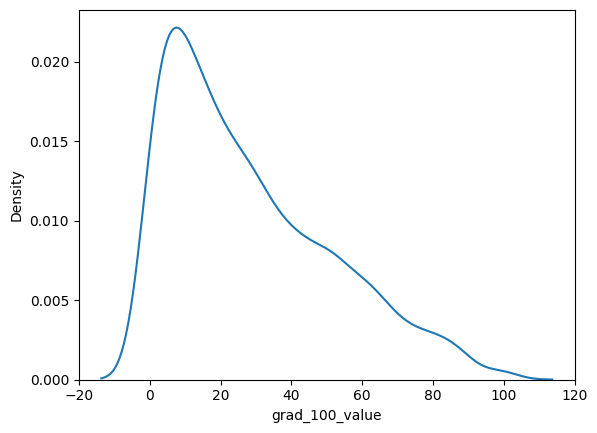

In [ ]:
#Question 5.4 (Part 1: regular kde plot)
df6['grad_100_value'] = pd.to_numeric(df6['grad_100_value'], errors='coerce')
sns.kdeplot(data=df6, x='grad_100_value')

In [ ]:
#Question 5.4 (Part 1: regular describe table)
df6['grad_100_value'].describe()

,grad_100_value
count,3467.000000
mean,28.364465
std,23.312730
min,0.000000
25%,9.000000
50%,22.500000
75%,43.650000
max,100.000000


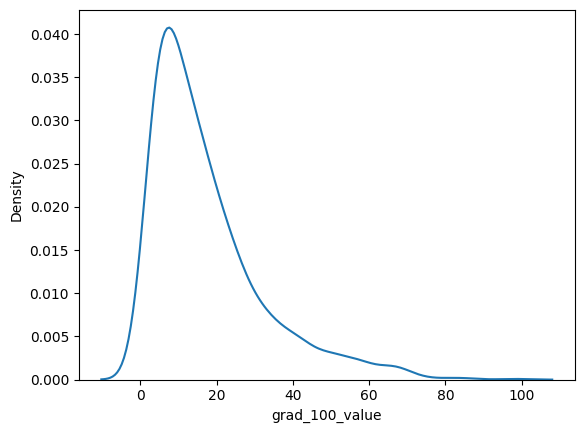

In [ ]:
#Question 5.4 (Part 2A: "Public" kde plot conditioned on control)
public = sns.kdeplot(data=df6[df6['control'] == 'Public'], x='grad_100_value')
plt.show()

In [ ]:
#Question 5.4 (Part 2A: "Public" describe table conditioned on control)
df6[df6['control'] == 'Public']['grad_100_value'].describe()

,grad_100_value
count,1499.000000
mean,17.430887
std,14.729443
min,0.000000
25%,6.900000
50%,13.200000
75%,23.250000
max,97.800000


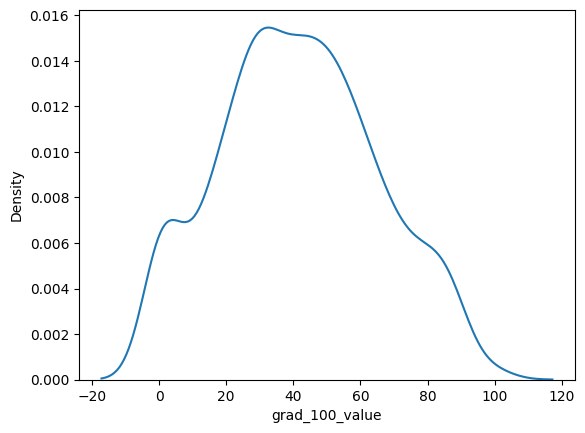

In [ ]:
#Question 5.4 (Part 2B: "Private not-for-profit" kde plot conditioned on control)
privatenp = sns.kdeplot(data=df6[df6['control'] == 'Private not-for-profit'], x='grad_100_value')
plt.show()

In [ ]:
#Question 5.4 (Part 2B: "Private not-for-profit" describe table conditioned on control)
df6[df6['control'] == 'Private not-for-profit']['grad_100_value'].describe()

,grad_100_value
count,1189.000000
mean,41.660976
std,23.551231
min,0.000000
25%,25.000000
50%,41.000000
75%,58.300000
max,100.000000


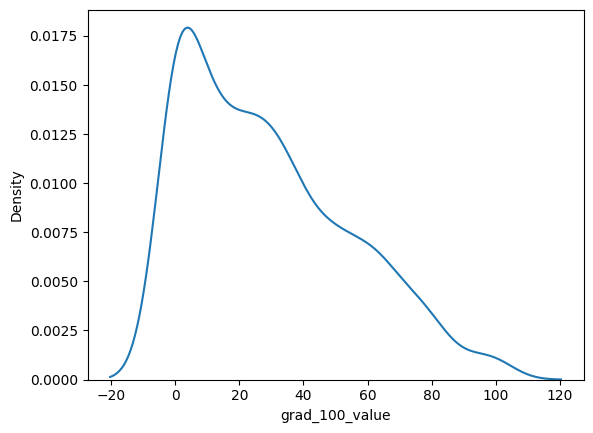

In [ ]:
#Question 5.4 (Part 2C: "Private for-profit" kde plot conditioned on control)
privatefp = sns.kdeplot(data=df6[df6['control'] == 'Private for-profit'], x='grad_100_value')
plt.show()

In [ ]:
#Question 5.4 (Part 2C: "Private for-profit" describe table conditioned on control)
df6[df6['control'] == 'Private for-profit']['grad_100_value'].describe()

,grad_100_value
count,779.000000
mean,29.108858
std,25.601687
min,0.000000
25%,6.950000
50%,24.700000
75%,46.750000
max,100.000000


#Question 5.4 (Part 3): Interpreting patterns
Private not for profit institutions have the most favorable graduation rates since the mean of the distribution is roughly around a grad value of 41.6, compared to the much lower mean grad values of the other institution control types (Private for profit mean was 29.1 and Public mean was 17.43).

<function matplotlib.pyplot.show(close=None, block=None)>

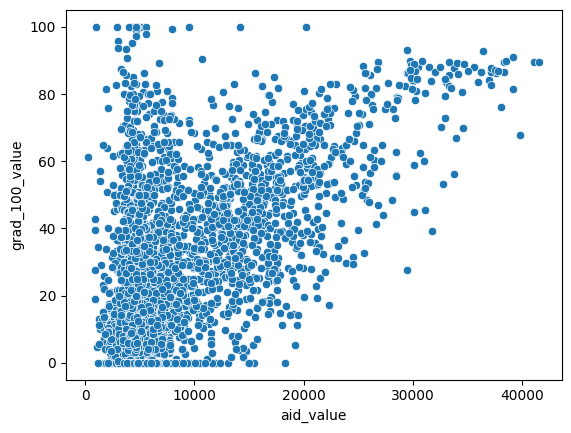

In [ ]:
#Question 5.5 (Part 1: regular scatterplot)
df6['aid_value'] = pd.to_numeric(df6['aid_value'], errors='coerce')
sns.scatterplot(data=df6, x = 'aid_value', y = 'grad_100_value')
plt.show

In [ ]:
#Question 5.5 (Part 1: regular covariance)
covariance = df6['aid_value'].cov(df6['grad_100_value'])
print(covariance)

#Note: I recognize that aid_value is measured in dollars and that is leading to the high covariance.

88610.48316902434


In [ ]:
#Question 5.5 (Part 1: regular correlation)
correlation = df6['aid_value'].corr(df6['grad_100_value'])
print(correlation)

0.5758792845936073


#Question 5.5 (Part 1: regular plots description of findings)
There is a positive relationship between aid_value and grad_100_value. I observed this from the scatterplot and this is validated by the positive correlation and covariance.

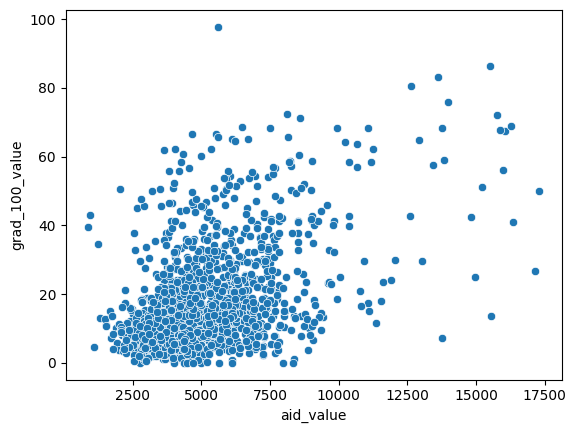

In [ ]:
#Question 5.5 (Part 2A: Public scatterplot)
public1 = sns.scatterplot(data=df6[df6['control'] == 'Public'], x = 'aid_value', y = 'grad_100_value')
plt.show()

In [ ]:
#Question 5.5 (Part 2A: Public covariance)
covariance1 = df6[df6['control'] == 'Public']['aid_value'].cov(df6[df6['control'] == 'Public']['grad_100_value'])
print(covariance1)

15355.146211760217


In [ ]:
#Question 5.5 (Part 2A: Public correlation)
correlation1 = df6[df6['control'] == 'Public']['aid_value'].corr(df6[df6['control'] == 'Public']['grad_100_value'])
print(correlation1)

0.4824810458983382


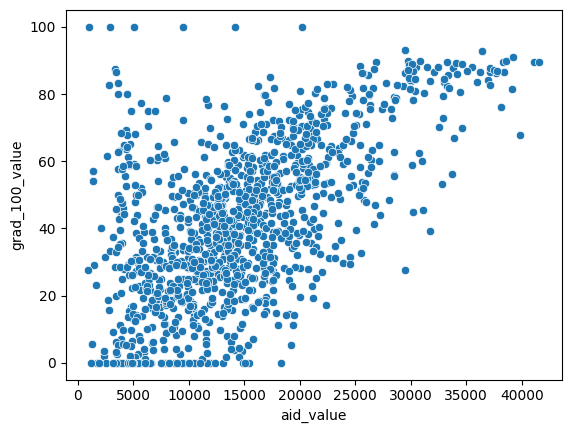

In [ ]:
#Question 5.5 (Part 2B: Private not-for-profit scatterplot)
privatenp1 = sns.scatterplot(data=df6[df6['control'] == 'Private not-for-profit'], x = 'aid_value', y = 'grad_100_value')
plt.show()

In [ ]:
#Question 5.5 (Part 2B: Private not-for-profit covariance)
covariance2 = df6[df6['control'] == 'Private not-for-profit']['aid_value'].cov(df6[df6['control'] == 'Private not-for-profit']['grad_100_value'])
print(covariance2)

109274.12333702881


In [ ]:
#Question 5.5 (Part 2B: Private not-for-profit correlation)
correlation2 = df6[df6['control'] == 'Private not-for-profit']['aid_value'].corr(df6[df6['control'] == 'Private not-for-profit']['grad_100_value'])
print(correlation2)

0.6015909241488573


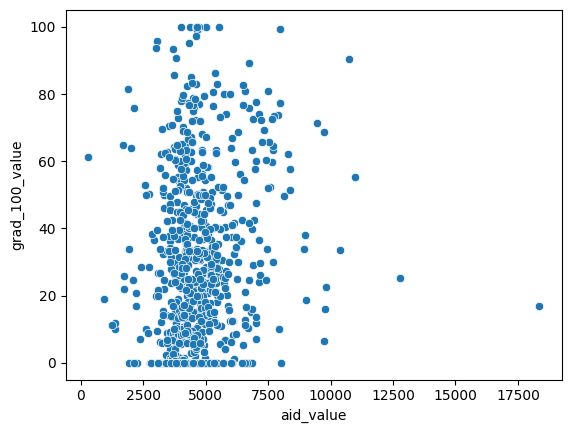

In [ ]:
#Question 5.5 (Part 2C: Private for-profit scatterplot)
privatefp1 = sns.scatterplot(data=df6[df6['control'] == 'Private for-profit'], x = 'aid_value', y = 'grad_100_value')
plt.show()

In [ ]:
#Question 5.5 (Part 2C: Private for-profit covariance)
covariance3 = df6[df6['control'] == 'Private for-profit']['aid_value'].cov(df6[df6['control'] == 'Private for-profit']['grad_100_value'])
print(covariance3)

6897.524957237808


In [ ]:
#Question 5.5 (Part 2C: Private for-profit correlation)
correlation3 = df6[df6['control'] == 'Private for-profit']['aid_value'].corr(df6[df6['control'] == 'Private for-profit']['grad_100_value'])
print(correlation3)

0.1883627008424557


#Question 5.5 (Part 3: description of findings)
Private not-for-profit institutions have a strong positive relationship with grad_100_value. It has the strongest correlation of 0.6. The scatterplot for Private not-for-profit also visually displays this strong relationship with a positive, upwards sloping pattern emerging.

**Q6.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

We're going to look at **linear transformations** of $X$, $Y = a + bX$. So we take each value of $X$, $x_i$, and transform it as $y_i = a + b x_i$.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $ \text{cov}(X,X) = s^2$.
3. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
4. Show that $\text{cov}(a+bX,a+bY) = b^2 \text{cov}(X,Y) $. Notice, this also means that $\text{cov}(bX, bX) = b^2 s^2$.
5. Suppose $b>0$ and let the median of $X$ be $\text{med}(X)$. Is it true that the median of $a+bX$ is equal to $a + b \times \text{med}(X)$? Is the IQR of $a + bX$ equal to $a + b \times \text{IQR}(X)$?
6. Show by example that the means of $X^2$ and $\sqrt{X}$ are generally not $(m(X))^2$ and $\sqrt{m(X)}$. So, the results we derived above really depend on the linearity of the transformation $Y = a + bX$, and transformations like $Y = X^2$ or $Y = \sqrt{X}$ will not behave in a similar way.

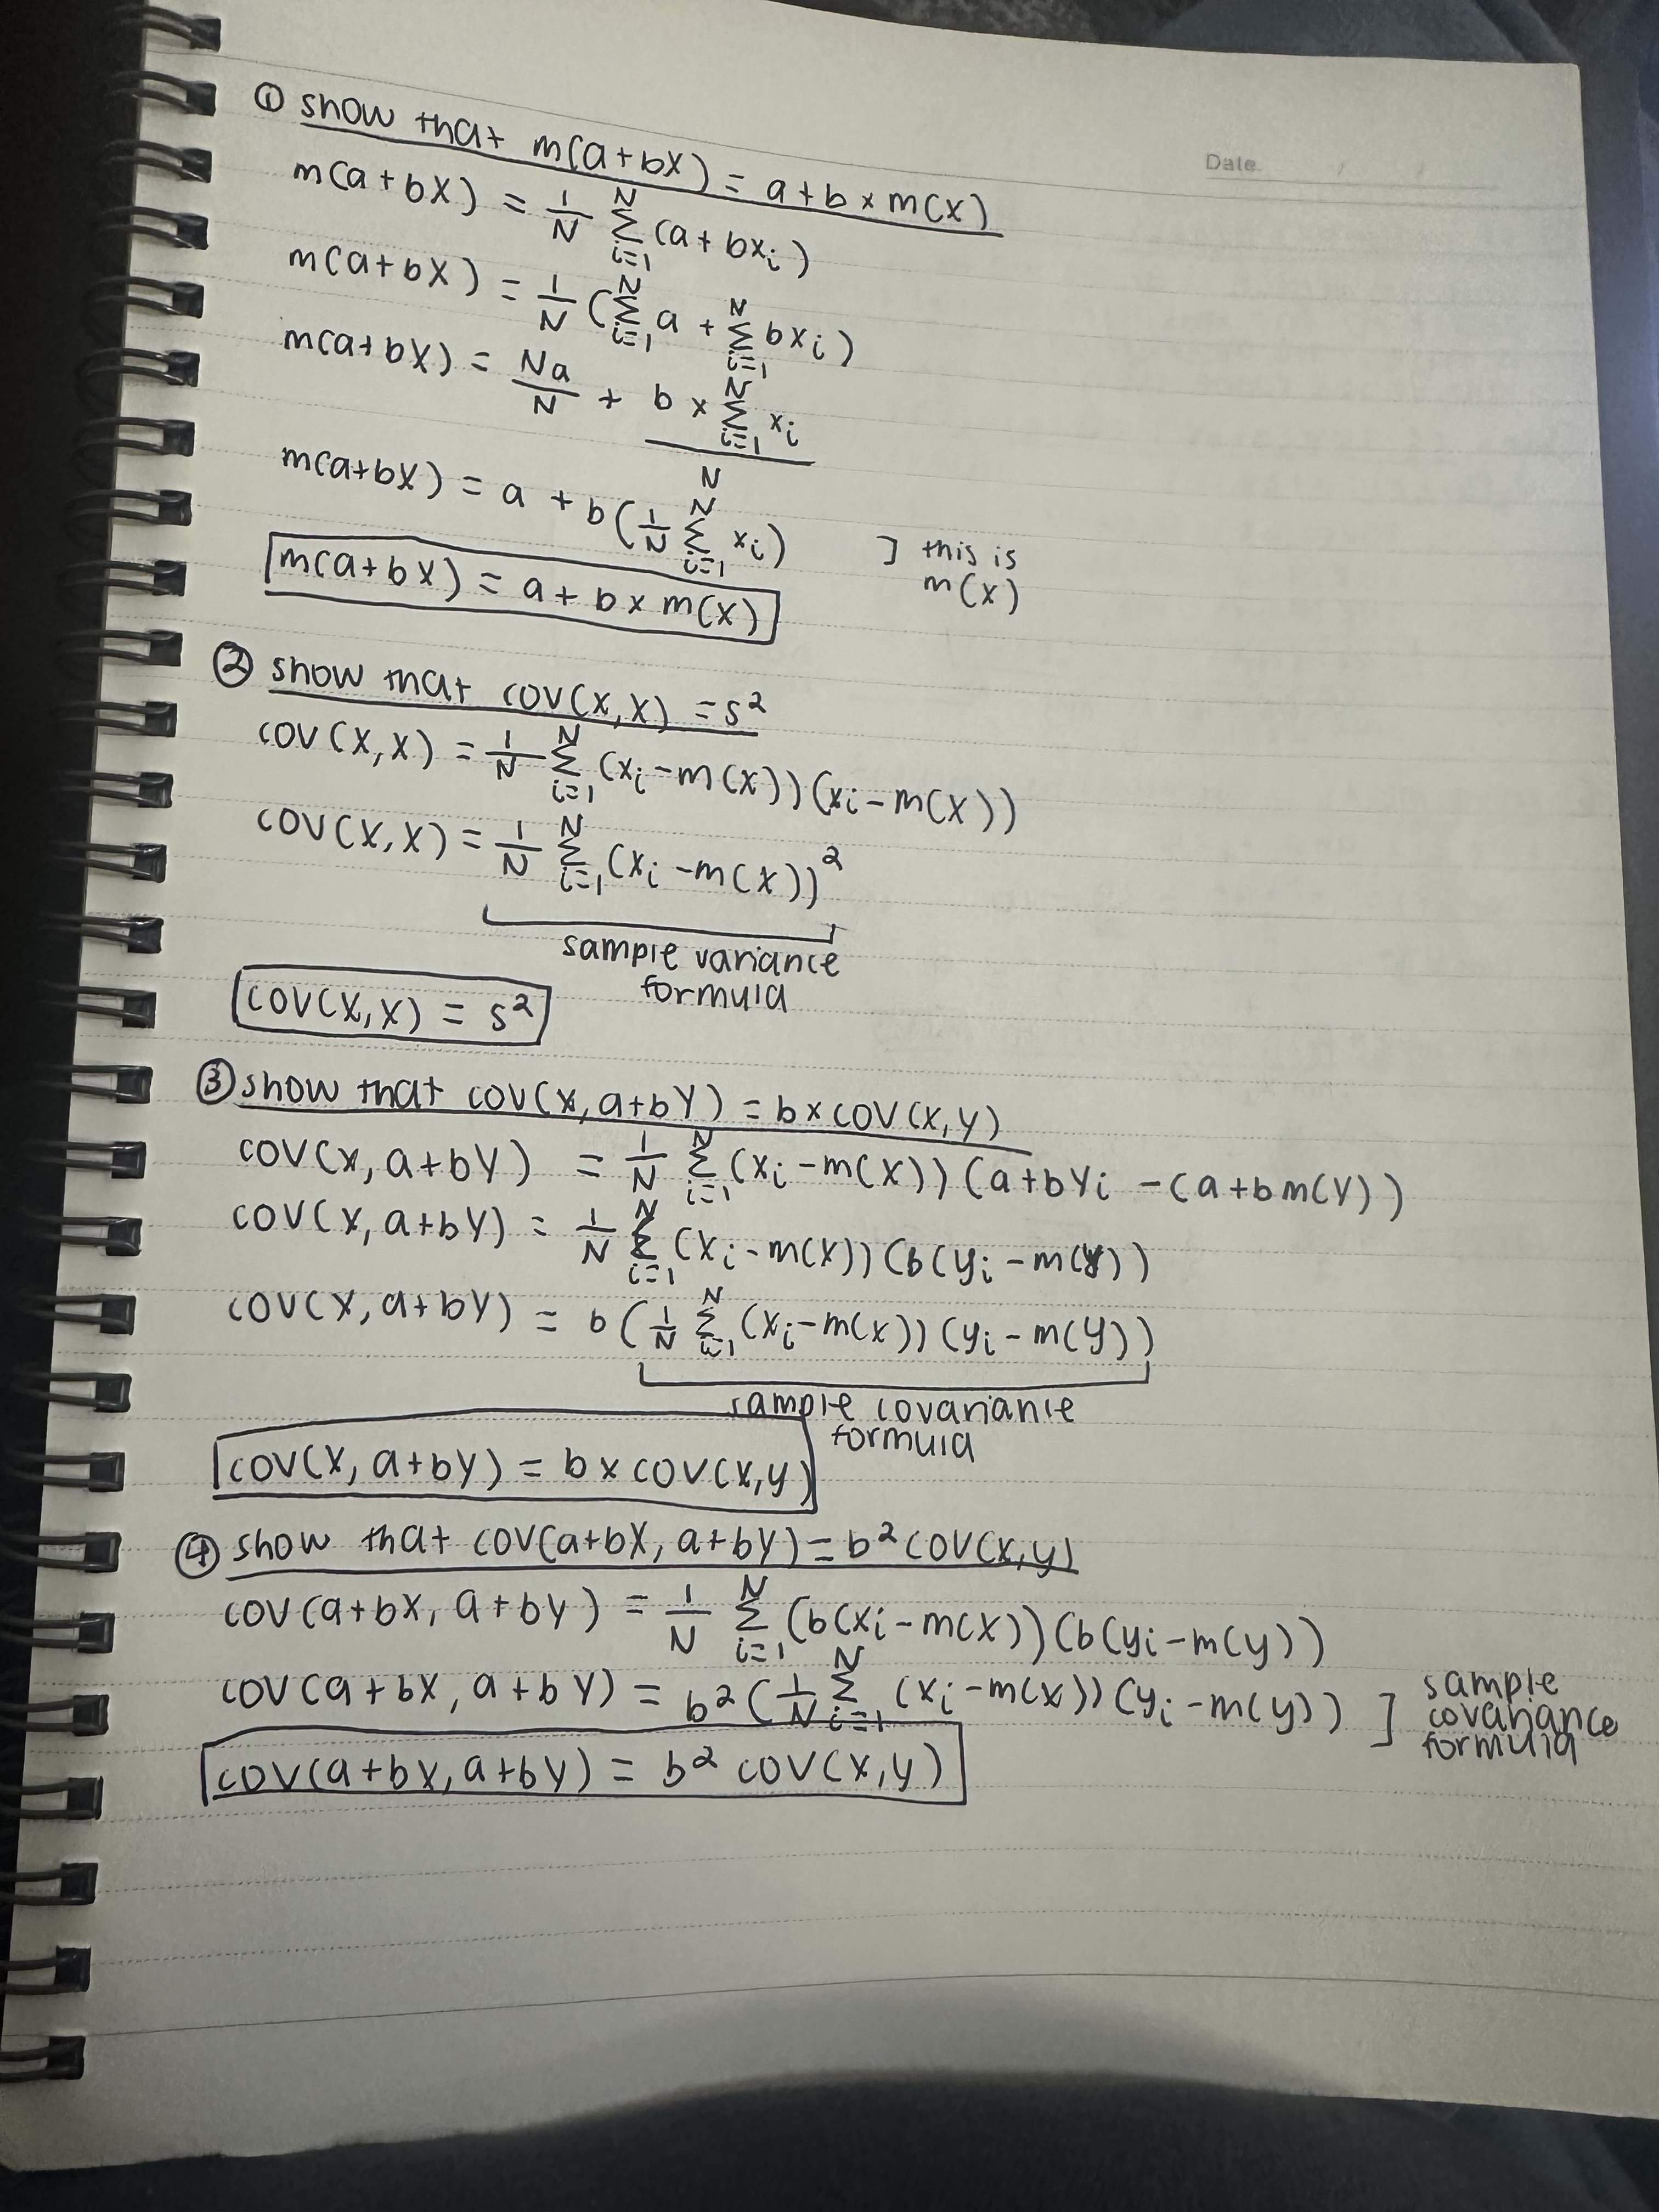

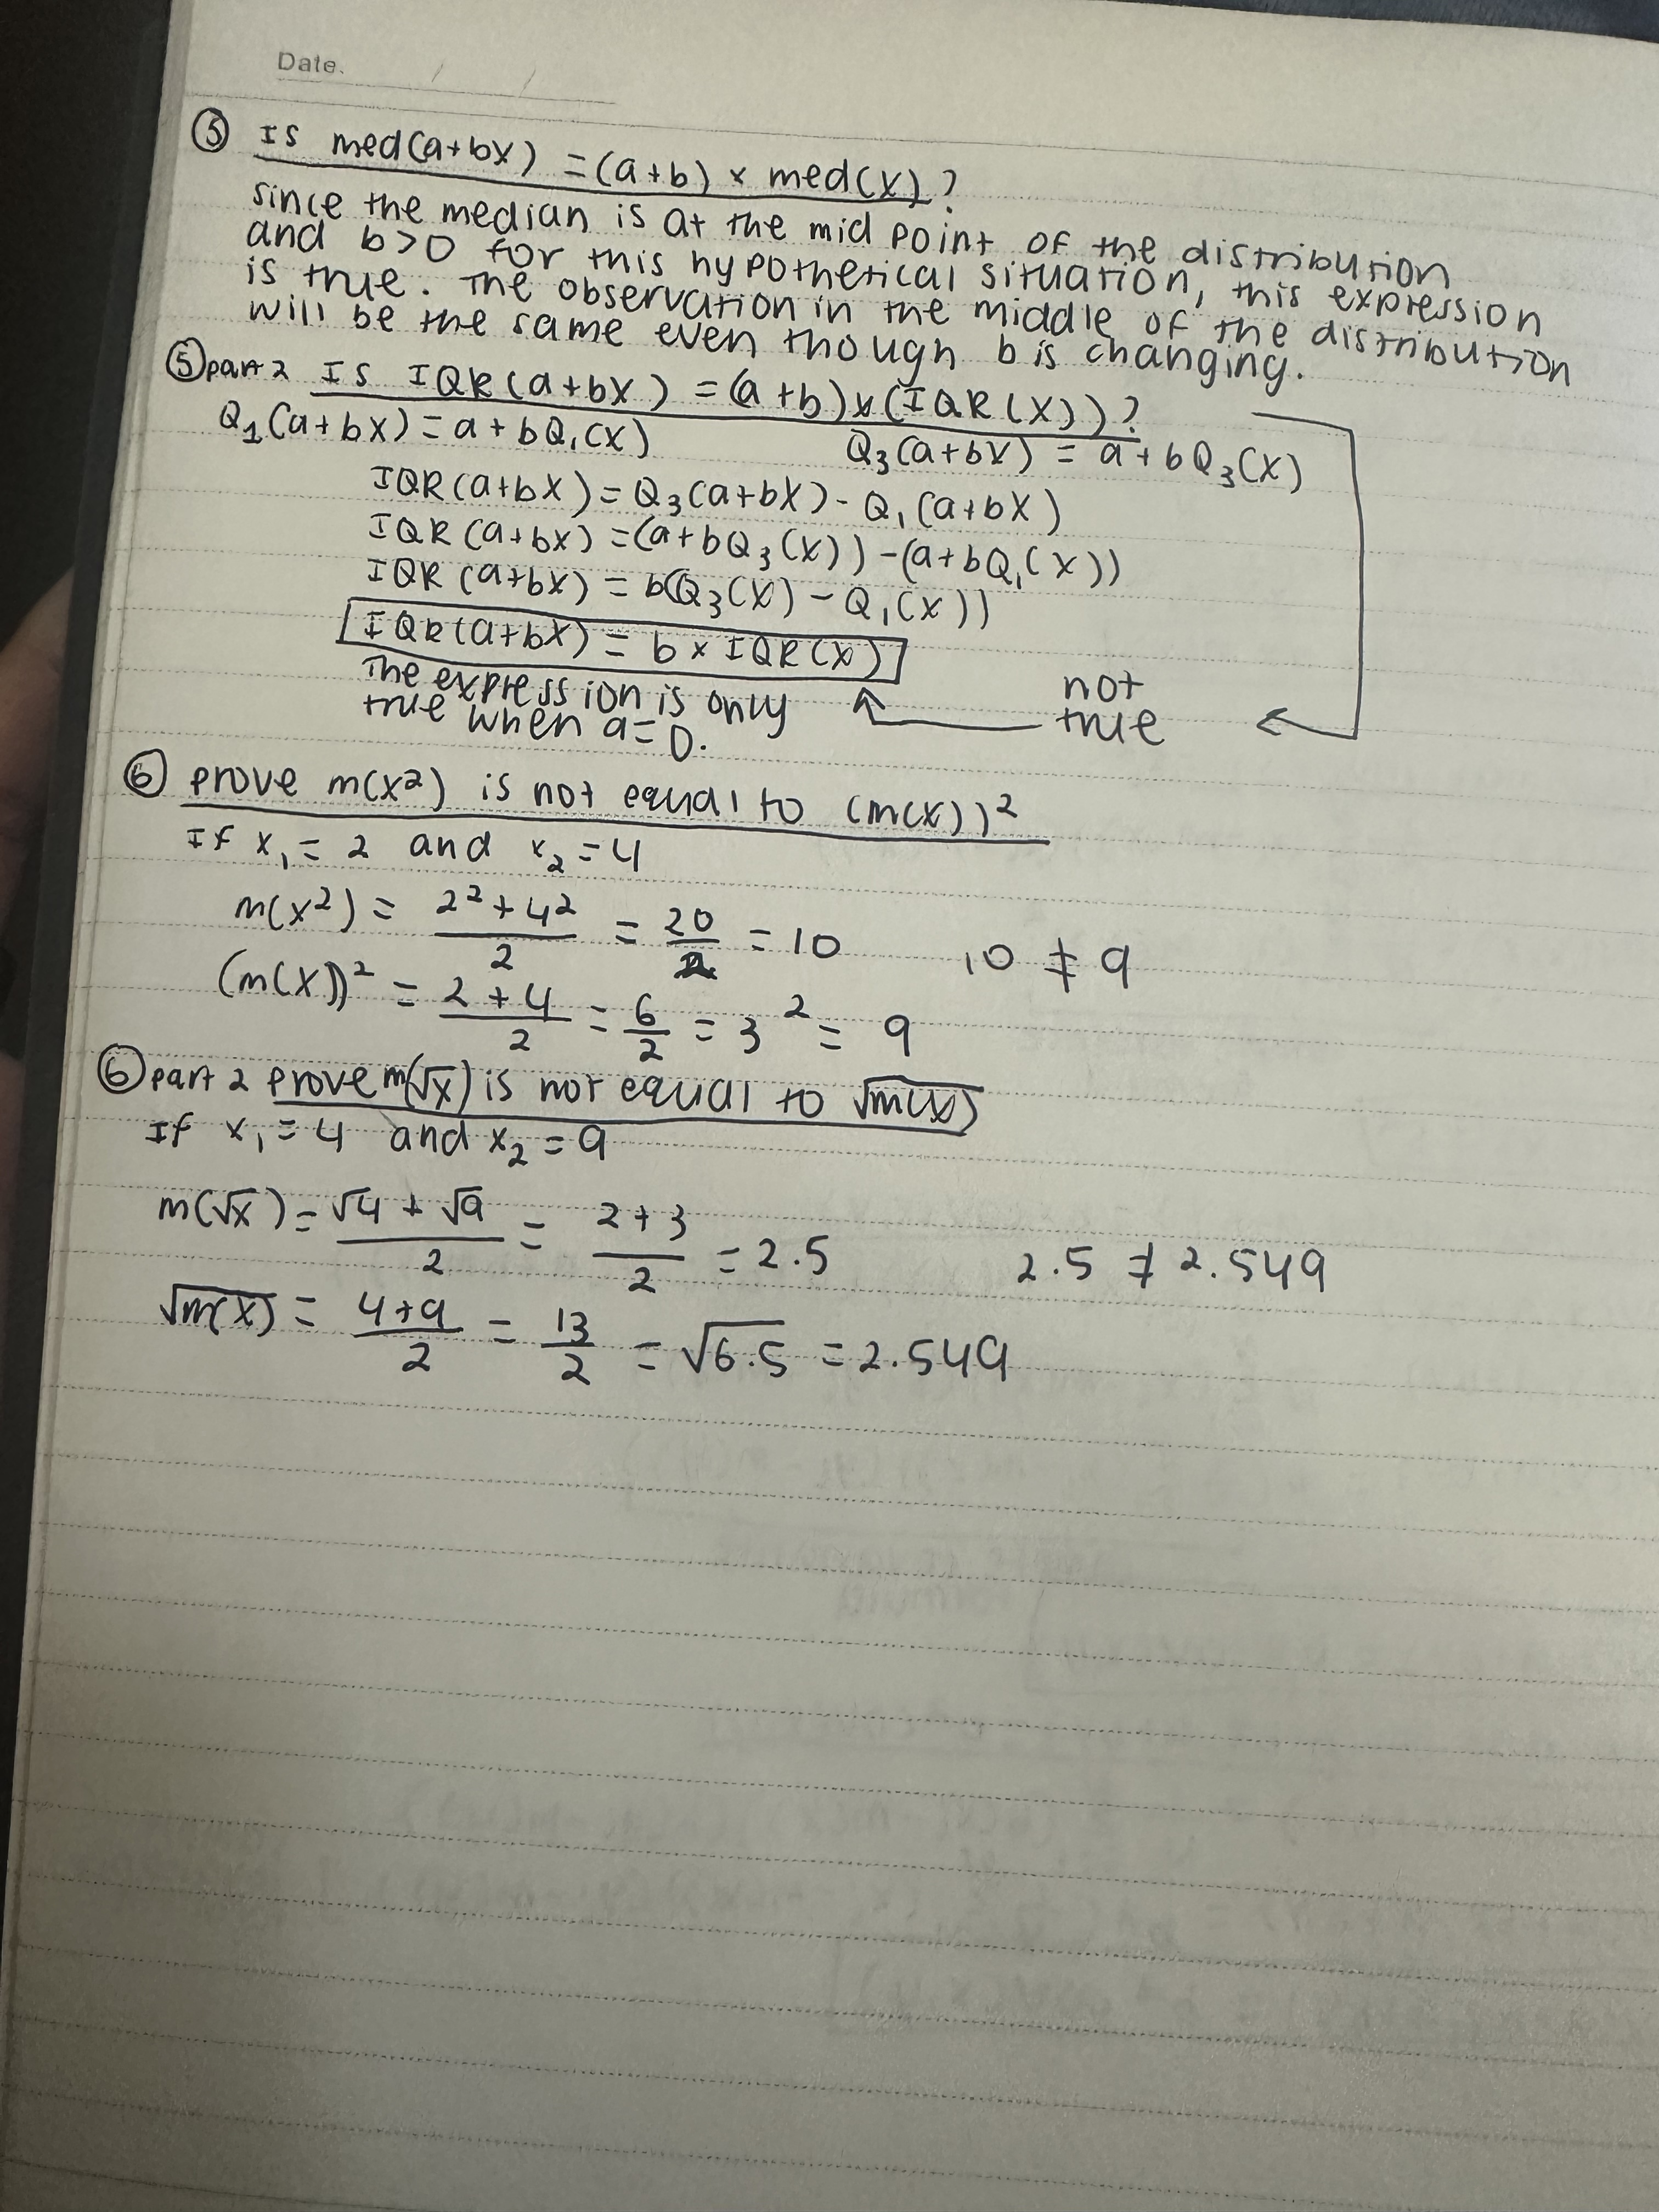

**Q7.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `ames_prices.csv` dataset. The "relevant" variables for this question are:
  - `price` - Sale price value of the house
  - `Bldg.Type` - Building type of the house (single family home, end-of-unit townhome, duplex, interior townhome, two-family conversion)

1. Load the `college_completion.csv` data with Pandas.
2. Make a kernel density plot of price and compute a describe table. Now, make a kernel density plot of price conditional on building type, and use `.groupby()` to make a describe type for each type of building. Which building types are the most expensive, on average? Which have the highest variance in transaction prices?
3. Make an ECDF plot of price, and compute the sample minimum, .25 quantile, median, .75 quantile, and sample maximum (i.e. a 5-number summary).
4. Make a boxplot of price. Are there outliers? Make a boxplot of price conditional on building type. What patterns do you see?
5. Make a dummy variable indicating that an observation is an outlier.
6. Winsorize the price variable, and compute a new kernel density plot and describe table. How do the results change?

In [21]:
#Question 7.1
#Load the dataset
df = pd.read_csv('/content/data/college_completion.csv')
df.head()

#Note: the question 7.1 asks to load college_completion but the question itself is about ames, so I imported both

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


In [32]:
#Question 7.1 (continued)
df7 = pd.read_csv('/content/data/ames_prices.csv')
df7.head()

,Order,PID,area,price,MS.SubClass,MS.Zoning,Lot.Frontage,Lot.Area,Street,Alley,...,Screen.Porch,Pool.Area,Pool.QC,Fence,Misc.Feature,Misc.Val,Mo.Sold,Yr.Sold,Sale.Type,Sale.Condition
0,1,526301100,1656,215000,20,RL,141.0,31770,Pave,NaN,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1,2,526350040,896,105000,20,RH,80.0,11622,Pave,NaN,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
2,3,526351010,1329,172000,20,RL,81.0,14267,Pave,NaN,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
3,4,526353030,2110,244000,20,RL,93.0,11160,Pave,NaN,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
4,5,527105010,1629,189900,60,RL,74.0,13830,Pave,NaN,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


<Axes: xlabel='price', ylabel='Density'>

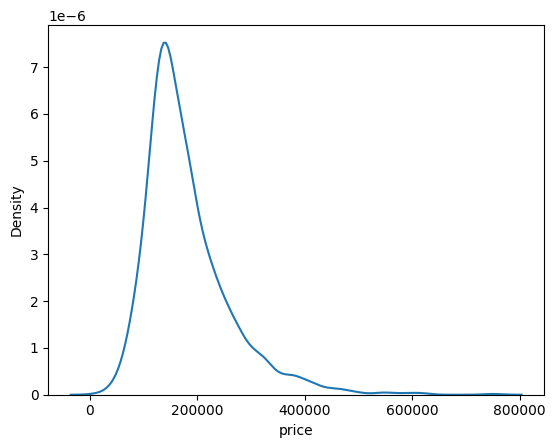

In [ ]:
#Question 7.2 (Part 1)
# KDE plot of price
sns.kdeplot(data=df7, x='price')

In [ ]:
#Question 7.2 (Part 2)
# KDE price describe table
df7['price'].describe()

,price
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


<Axes: xlabel='price', ylabel='Density'>

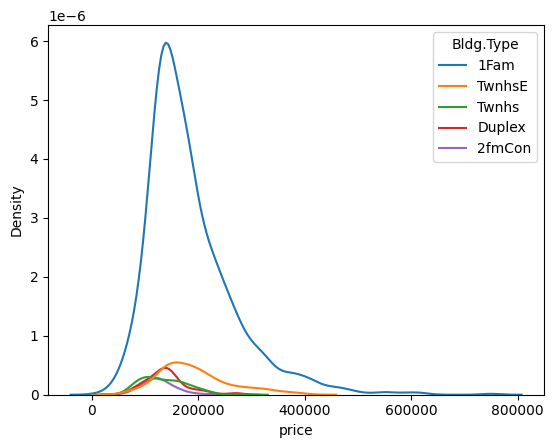

In [ ]:
#Question 7.2 (Part 3)
#KDE plot of price conditional on building type
sns.kdeplot(data=df7, x='price', hue='Bldg.Type')

In [ ]:
#Question 7.2 (Part 4)
#Describe table of price conditional on building type
df7.groupby('Bldg.Type')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
Bldg.Type,,,,,,,,
1Fam,2425.0,184812.041237,82821.802329,12789.0,130000.0,165000.0,220000.0,755000.0
2fmCon,62.0,125581.709677,31089.239840,55000.0,106562.5,122250.0,140000.0,228950.0
Duplex,109.0,139808.935780,39498.973534,61500.0,118858.0,136905.0,153337.0,269500.0
Twnhs,101.0,135934.059406,41938.931130,73000.0,100500.0,130000.0,170000.0,280750.0
TwnhsE,233.0,192311.914163,66191.738021,71000.0,145000.0,180000.0,222000.0,392500.0


#Question 7.2 final response:

TownhomesE are the most expensive on average as seen by this building type having the highest mean price. Single Family homes have the greatest variance in price as observed by the highest standard deviation of all building types.

<Axes: xlabel='price', ylabel='Proportion'>

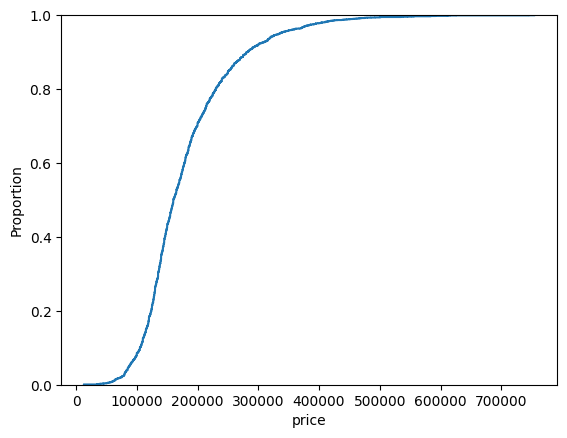

In [ ]:
#Question 7.3 (Part 1)
#ECDF Plot of price
sns.ecdfplot(data=df7, x='price')

In [ ]:
#Question 7.3 (Part 2)
#5-number summary
df7['price'].describe()[['min', '25%', '50%', '75%', 'max']]

,price
min,12789.0
25%,129500.0
50%,160000.0
75%,213500.0
max,755000.0


<Axes: xlabel='price'>

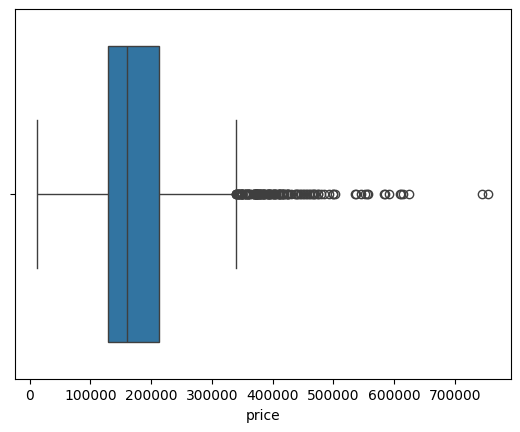

In [23]:
#Question 7.4 (Part 1)
# Boxplot of price
sns.boxplot(data=df7, x='price')

#There are outliers, as observed in the boxplot below.

<Axes: xlabel='Bldg.Type', ylabel='price'>

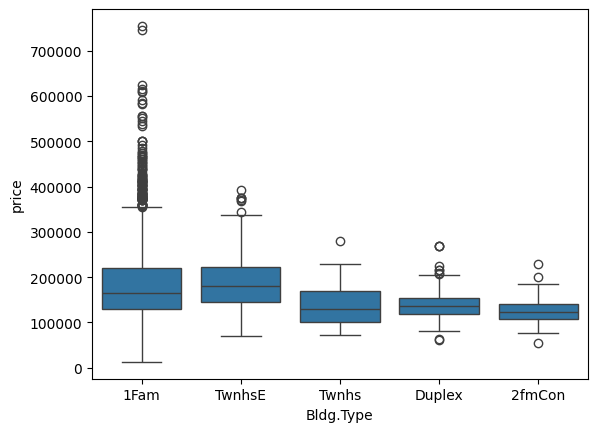

In [ ]:
#Question 7.4 (Part 2)
# Boxplot of price conditional on building type
sns.boxplot(data=df7, x='Bldg.Type', y='price')

#Question 7.4 (Part 3): Boxplot Patterns

Regular townhomes and 2fmCon have the lowest median price. Townhomes E have the highest median price. Single family homes have the most outliers / variability.

In [33]:
#Question 7.5
# Dummy variable for for finding outliers
IQR = (df7['price'].quantile(0.75))-(df7['price'].quantile(0.25))

lower_bound = (df7['price'].quantile(0.25))-(1.5*IQR)
upper_bound = (df7['price'].quantile(0.75))+(1.5*IQR)

df7['outlier'] = ((df7['price'] < lower_bound) | (df7['price'] > upper_bound)).astype(int)
df7['outlier'].value_counts()
#0 means that the observation is not an outlier
#1 means the observation is an outlier

,count
outlier,
0,2793
1,137


<Axes: xlabel='price', ylabel='Density'>

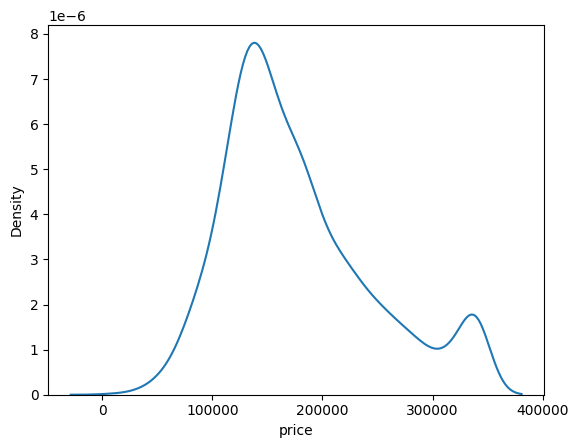

In [34]:
#Question 7.6 (Part 1)
#Winsorizing the price variable
df7['price'] = df7['price'].clip(lower_bound, upper_bound)

#KDE plot
sns.kdeplot(data=df7, x='price')

In [35]:
#Question 7.6 (Part 2)
#New describe table
df7['price'].describe()

,price
count,2930.000000
mean,177082.283959
std,67906.837135
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,339500.000000


#Question 7.6 (Part 3): Results

The original price kde plot had a long right tail that had low density, but the winsorized kde plot hid some of that long tail, hiding some of the major outliers in the distribution. Additionally, the winsorized kde plot has a bimodal bump that was hidden by the outliers from the original plot.